In [1]:
#%pip install openai
#%pip install typing-extensions
#%pip install matplotlib seaborn
#%pip install datasets transformers==4.38.2
#%pip install torch
#%pip install vllm
#%pip install --upgrade transformers

In [2]:
from experiments_vllm import *
from experiments_forced_imbalance import *
from data import *
from transformers import AutoTokenizer
import torch
from config import *

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
# Environment fixes
import os
os.environ["FLASHINFER_DISABLE_VERSION_CHECK"] = "1"

In [4]:
# Set seeds
seed = 43
torch.manual_seed(seed);

In [5]:
# Create imbalanced models
model_path_balanced = f'./vllm_benchmarking/models/mixtral-imbalance{imbalance_level_low}_layers{n_layers}_n{n_local_experts}_k{k}_hiddensize{hidden_size}_intermediatesize{intermediate_size}'
if not os.path.isdir(model_path_balanced):
    generate_imbalanced_moe(imbalance_level_low, model_path_balanced, n_layers=n_layers, n_local_experts=n_local_experts, k=k,
                            hidden_size=hidden_size, intermediate_size=hidden_size)


model_path_imbalanced = f'./vllm_benchmarking/models/mixtral-imbalance{imbalance_level_high}_layers{n_layers}_n{n_local_experts}_k{k}_hiddensize{hidden_size}_intermediatesize{intermediate_size}'
if not os.path.isdir(model_path_imbalanced):
    generate_imbalanced_moe(imbalance_level_high, model_path_imbalanced, n_layers=n_layers, n_local_experts=n_local_experts, k=k,
                            hidden_size=hidden_size, intermediate_size=hidden_size)

Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

MoEHook: Scanning model for routers...
MoEHook: Attached probes to 8 router layers.
MoEHook: Model has 8 routers each with 8 experts and selects k=1 at each layer.


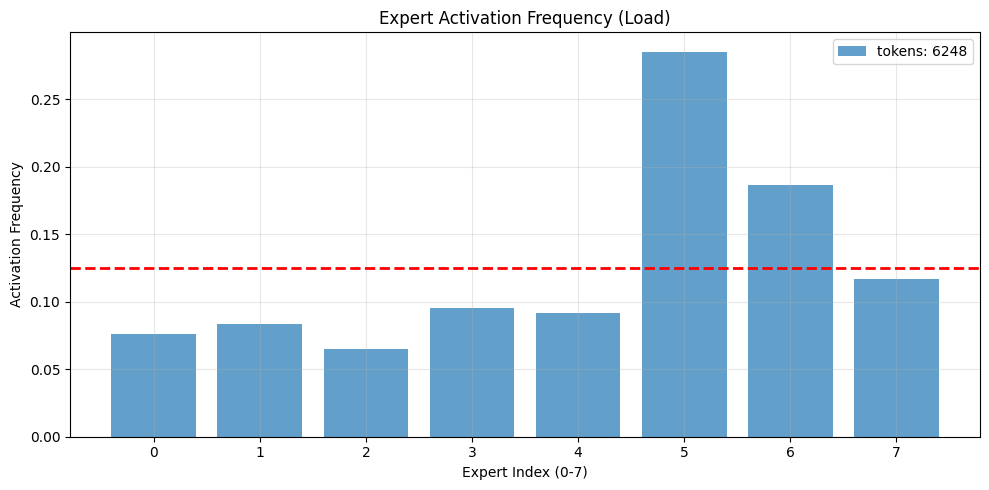

In [6]:
# Confirm imbalance
prompts = ["Describe the concept of Mixture in Experts in detail.",
           "Translate 'Good morning, how are you today?' into Indonesian.",
           "What is 45 multiplied by 12?",
           "Write a one-sentence definition of photosynthesis.",
           "Sort these words alphabetically: banana, apple, cherry, date.",
           "Complete the phrase: To be, or not to be, that is the..."]
#prompts *= 10

model_balanced = AutoModelForCausalLM.from_pretrained(model_path_balanced, device_map="auto")
probe = MoEProbeMistral(model_balanced)
tokenizer = AutoTokenizer.from_pretrained(model_path_balanced)
for prompt in prompts:
    response, probs, active_experts = single_generate(model_balanced, tokenizer, probe,
                                                      prompt=prompt, max_new_tokens=max_new_tokens,
                                                      clear_probe=False)
probe.plot_loadbalance(router_id=0)

Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

MoEHook: Scanning model for routers...
MoEHook: Attached probes to 8 router layers.
MoEHook: Model has 8 routers each with 8 experts and selects k=1 at each layer.


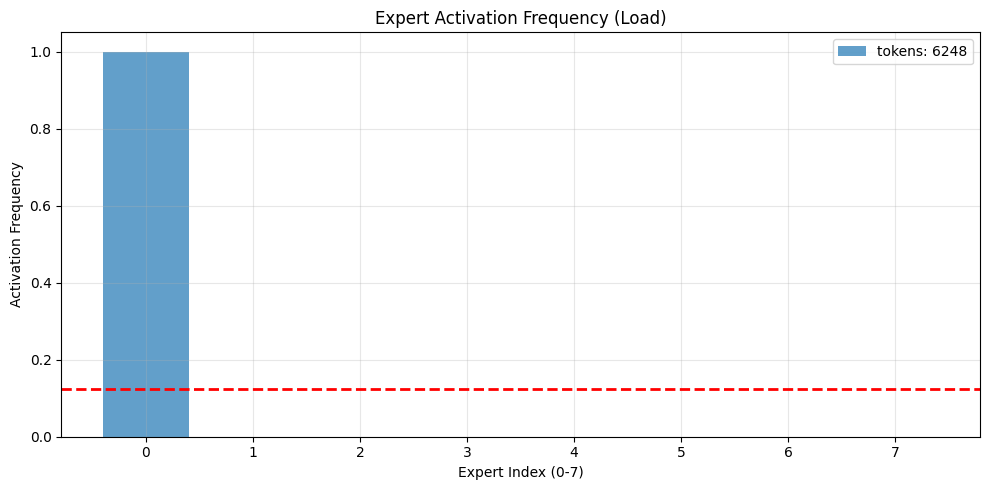

In [7]:
model_imbalanced = AutoModelForCausalLM.from_pretrained(model_path_imbalanced, device_map="auto")
probe = MoEProbeMistral(model_imbalanced)
tokenizer = AutoTokenizer.from_pretrained(model_path_imbalanced)
for prompt in prompts:
    response, probs, active_experts = single_generate(model_imbalanced, tokenizer, probe,
                                                      prompt=prompt, max_new_tokens=max_new_tokens,
                                                      clear_probe=False)
probe.plot_loadbalance(router_id=0)

In [8]:
# Use MMLU questions
dataset = get_data_mmlu(n_samples=n_samples, shuffle_seed=seed)
mmlu_prompts = format_prompts_mmlu(dataset, prompt_reps=prompt_reps)

Streaming cais/mmlu (all) (samples: 100)...


In [9]:
# Make trace directories
if not os.path.isdir(trace_path_balanced):
    os.mkdir(trace_path_balanced)
if not os.path.isdir(trace_path_imbalanced):
    os.mkdir(trace_path_imbalanced)

In [10]:
# Run experiment over generalized MMLU questions
balanced_results = await run_experiment_vllm_throughput(model_path_balanced,
                                                           mmlu_prompts,
                                                           seed=seed,
                                                           max_new_tokens=max_new_tokens,
                                                           max_model_len=max_model_len,
                                                           batch_size=batch_size,
                                                           concurrency_limit=batch_size*4,
                                                           gpu_memory_utilization=gpu_memory_utilization,
                                                           n_gpus=n_gpus,
                                                           n_warmup_samples=n_warmup_samples,
                                                           print_output=False,
                                                           enable_expert_parallel=enable_expert_parallel,
                                                           enable_prefix_caching=enable_prefix_caching,
                                                           trace_dir=trace_path_balanced)

Starting vLLM server for ./vllm_benchmarking/models/mixtral-imbalance0_layers8_n8_k1_hiddensize2048_intermediatesize8192...
Waiting for server to initialize ...
WARNING 08-10 12:42:13 [profiler.py:140] Using 'torch' profiler with delay_iterations or max_iterations while ignore_frontend is False may result in high overhead.
(APIServer pid=1539222) INFO 08-10 12:42:13 [api_utils.py:345] 
(APIServer pid=1539222) INFO 08-10 12:42:13 [api_utils.py:345]        █     █     █▄   ▄█
(APIServer pid=1539222) INFO 08-10 12:42:13 [api_utils.py:345]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.26.0
(APIServer pid=1539222) INFO 08-10 12:42:13 [api_utils.py:345]   █▄█▀ █     █     █     █  model   ./vllm_benchmarking/models/mixtral-imbalance0_layers8_n8_k1_hiddensize2048_intermediatesize8192
(APIServer pid=1539222) INFO 08-10 12:42:13 [api_utils.py:345]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=1539222) INFO 08-10 12:42:13 [api_utils.py:345] 
(APIServer pid=1539222) INFO 08-10 12:42:14 [api_utils.py:273] non

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.23it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.23it/s]
(Worker_TP0_EP0 pid=1539348) 


(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:38 [default_loader.py:430] Loading weights took 0.95 seconds
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:38 [unquantized.py:374] Using MoEPrepareAndFinalizeNoDPEPModular
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:38 [unquantized.py:375] Using TritonExperts MoE backend
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:39 [gpu_model_runner.py:5347] Model loading took 0.97 GiB memory and 1.202550 seconds
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:43 [backends.py:1094] Using cache directory: /home/dylan/.cache/vllm/torch_compile_cache/39df8f44c7/rank_0_0/backbone for vLLM's torch.compile
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:43 [backends.py:1155] Dynamo bytecode transform time: 3.90 s


(Worker_TP1_EP1 pid=1539349) [rank1]:W0810 12:42:45.112000 1539349 torch/_inductor/utils.py:1731] Not enough SMs to use max_autotune_gemm mode
(Worker_TP0_EP0 pid=1539348) [rank0]:W0810 12:42:45.117000 1539348 torch/_inductor/utils.py:1731] Not enough SMs to use max_autotune_gemm mode


(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:48 [backends.py:378] Cache the graph of compile range (1, 2048) for later use
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:51 [backends.py:393] Compiling a graph for compile range (1, 2048) takes 7.58 s
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:52 [decorators.py:708] saved AOT compiled function to /home/dylan/.cache/vllm/torch_compile_cache/torch_aot_compile/2590ca948dfa150828d72e8965fe6e69c6120d5799dbf506554e3ec23ee3f8f5/rank_0_0/model
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:42:52 [monitor.py:53] torch.compile took 12.85 s in total
(Worker_TP0_EP0 pid=1539348) WARNING 08-10 12:42:53 [fused_moe.py:1107] Using default MoE config. Performance might be sub-optimal! Config file not found at /home/dylan/.local/lib/python3.10/site-packages/vllm/model_executor/layers/fused_moe/configs/E=4,N=2048,device_name=Quadro_RTX_5000.json
(Worker_TP0_EP0 pid=1539348) INFO 08-10 12:43:00 [monitor.py:81] Initial profiling/warmup run took 7.48 s
(Worker

...

(Worker_TP1_EP1 pid=1539349) /home/dylan/.local/lib/python3.10/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
(Worker_TP1_EP1 pid=1539349)   _warn_once(
(Worker_TP0_EP0 pid=1539348) /home/dylan/.local/lib/python3.10/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
(Worker_TP0_EP0 pid=1539348)   _warn_once(


(APIServer pid=1539222) INFO 08-10 12:44:02 [loggers.py:310] Engine 000: Avg prompt throughput: 245.2 tokens/s, Avg generation throughput: 135.6 tokens/s, Running: 16 reqs, Waiting: 84 reqs, GPU KV cache usage: 0.4%, Prefix cache hit rate: 0.0%
(APIServer pid=1539222) INFO 08-10 12:44:12 [loggers.py:310] Engine 000: Avg prompt throughput: 251.5 tokens/s, Avg generation throughput: 124.7 tokens/s, Running: 16 reqs, Waiting: 68 reqs, GPU KV cache usage: 0.3%, Prefix cache hit rate: 0.0%
(APIServer pid=1539222) INFO 08-10 12:44:22 [loggers.py:310] Engine 000: Avg prompt throughput: 251.3 tokens/s, Avg generation throughput: 158.3 tokens/s, Running: 16 reqs, Waiting: 52 reqs, GPU KV cache usage: 0.3%, Prefix cache hit rate: 0.0%
(APIServer pid=1539222) INFO 08-10 12:44:32 [loggers.py:310] Engine 000: Avg prompt throughput: 249.9 tokens/s, Avg generation throughput: 161.5 tokens/s, Running: 16 reqs, Waiting: 36 reqs, GPU KV cache usage: 0.3%, Prefix cache hit rate: 0.0%
(APIServer pid=15392

(APIServer pid=1539222) INFO:     Shutting down
(APIServer pid=1539222) INFO:     Waiting for application shutdown.
(APIServer pid=1539222) INFO:     Application shutdown complete.


Server successfully shut down.


/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 2 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 4 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '


In [11]:
imbalanced_results = await run_experiment_vllm_throughput(model_path_imbalanced,
                                                             mmlu_prompts,
                                                             seed=seed,
                                                             max_new_tokens=max_new_tokens,
                                                             max_model_len=max_model_len,
                                                             batch_size=batch_size,
                                                             concurrency_limit=batch_size*4,
                                                             gpu_memory_utilization=gpu_memory_utilization,
                                                             n_gpus=n_gpus,
                                                             n_warmup_samples=n_warmup_samples,
                                                             print_output=False,
                                                             enable_expert_parallel=enable_expert_parallel,
                                                             enable_prefix_caching=enable_prefix_caching,
                                                             trace_dir=trace_path_imbalanced)

Starting vLLM server for ./vllm_benchmarking/models/mixtral-imbalance100_layers8_n8_k1_hiddensize2048_intermediatesize8192...
Waiting for server to initialize ...
WARNING 08-10 12:45:48 [profiler.py:140] Using 'torch' profiler with delay_iterations or max_iterations while ignore_frontend is False may result in high overhead.
(APIServer pid=1539824) INFO 08-10 12:45:48 [api_utils.py:345] 
(APIServer pid=1539824) INFO 08-10 12:45:48 [api_utils.py:345]        █     █     █▄   ▄█
(APIServer pid=1539824) INFO 08-10 12:45:48 [api_utils.py:345]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.26.0
(APIServer pid=1539824) INFO 08-10 12:45:48 [api_utils.py:345]   █▄█▀ █     █     █     █  model   ./vllm_benchmarking/models/mixtral-imbalance100_layers8_n8_k1_hiddensize2048_intermediatesize8192
(APIServer pid=1539824) INFO 08-10 12:45:48 [api_utils.py:345]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=1539824) INFO 08-10 12:45:48 [api_utils.py:345] 
(APIServer pid=1539824) INFO 08-10 12:45:48 [api_utils.py:273]

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.21it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.21it/s]
(Worker_TP0_EP0 pid=1539951) 


(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:13 [default_loader.py:430] Loading weights took 0.89 seconds
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:13 [unquantized.py:374] Using MoEPrepareAndFinalizeNoDPEPModular
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:13 [unquantized.py:375] Using TritonExperts MoE backend
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:14 [gpu_model_runner.py:5347] Model loading took 0.97 GiB memory and 1.141852 seconds
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:18 [backends.py:1094] Using cache directory: /home/dylan/.cache/vllm/torch_compile_cache/47f6de3df4/rank_0_0/backbone for vLLM's torch.compile
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:18 [backends.py:1155] Dynamo bytecode transform time: 3.86 s


(Worker_TP1_EP1 pid=1539952) [rank1]:W0810 12:46:19.730000 1539952 torch/_inductor/utils.py:1731] Not enough SMs to use max_autotune_gemm mode
(Worker_TP0_EP0 pid=1539951) [rank0]:W0810 12:46:19.750000 1539951 torch/_inductor/utils.py:1731] Not enough SMs to use max_autotune_gemm mode


(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:22 [backends.py:378] Cache the graph of compile range (1, 2048) for later use
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:26 [backends.py:393] Compiling a graph for compile range (1, 2048) takes 7.54 s
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:27 [decorators.py:708] saved AOT compiled function to /home/dylan/.cache/vllm/torch_compile_cache/torch_aot_compile/716739da4aa9501236ff5156140fd3c027c077df4fe9e206d2d8c6899bcb3ec0/rank_0_0/model
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:27 [monitor.py:53] torch.compile took 12.81 s in total
(Worker_TP0_EP0 pid=1539951) WARNING 08-10 12:46:27 [fused_moe.py:1107] Using default MoE config. Performance might be sub-optimal! Config file not found at /home/dylan/.local/lib/python3.10/site-packages/vllm/model_executor/layers/fused_moe/configs/E=4,N=2048,device_name=Quadro_RTX_5000.json
(Worker_TP0_EP0 pid=1539951) INFO 08-10 12:46:34 [monitor.py:81] Initial profiling/warmup run took 7.51 s
(Worker

...

(Worker_TP1_EP1 pid=1539952) /home/dylan/.local/lib/python3.10/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
(Worker_TP1_EP1 pid=1539952)   _warn_once(
(Worker_TP0_EP0 pid=1539951) /home/dylan/.local/lib/python3.10/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
(Worker_TP0_EP0 pid=1539951)   _warn_once(


(APIServer pid=1539824) INFO 08-10 12:47:37 [loggers.py:310] Engine 000: Avg prompt throughput: 249.4 tokens/s, Avg generation throughput: 160.0 tokens/s, Running: 13 reqs, Waiting: 71 reqs, GPU KV cache usage: 0.2%, Prefix cache hit rate: 0.0%
(APIServer pid=1539824) INFO 08-10 12:47:47 [loggers.py:310] Engine 000: Avg prompt throughput: 502.7 tokens/s, Avg generation throughput: 320.0 tokens/s, Running: 13 reqs, Waiting: 39 reqs, GPU KV cache usage: 0.2%, Prefix cache hit rate: 0.0%
(APIServer pid=1539824) INFO 08-10 12:47:57 [loggers.py:310] Engine 000: Avg prompt throughput: 492.7 tokens/s, Avg generation throughput: 177.3 tokens/s, Running: 16 reqs, Waiting: 20 reqs, GPU KV cache usage: 0.3%, Prefix cache hit rate: 0.0%
(APIServer pid=1539824) INFO 08-10 12:48:07 [loggers.py:310] Engine 000: Avg prompt throughput: 315.6 tokens/s, Avg generation throughput: 334.3 tokens/s, Running: 4 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.1%, Prefix cache hit rate: 0.0%
Stopping vLLM PyTorch 

(APIServer pid=1539824) INFO:     Shutting down
(APIServer pid=1539824) INFO:     Waiting for application shutdown.
(APIServer pid=1539824) INFO:     Application shutdown complete.


Server successfully shut down.


/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 2 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 4 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '


In [12]:
# Save results
import pickle
with open(results_file_balanced, 'wb') as file:
    pickle.dump(balanced_results, file)
with open(results_file_imbalanced, 'wb') as file:
    pickle.dump(imbalanced_results, file)